# 🎬 MovieLens 32M — A Full Data-Science Pipeline

**What we're building:** a *movie recommender* — a system that learns each
person's taste from the movies they've rated and predicts what they'd enjoy
next. This is the same idea behind Netflix's "Top Picks for You".

**The dataset:** [MovieLens 32M](https://grouplens.org/datasets/movielens/32m/)
— **32 million** ratings from ~200,000 people on ~84,000 movies, collected by
the University of Minnesota's GroupLens research lab.

**How this notebook is organised** — a classic data-science pipeline, one step
per section:

| Step | Section | Question it answers |
|------|---------|--------------------|
| 1. Load | Get the data | What do we actually have? |
| 2. Sample | Cut it down | How do we make 32M rows runnable in class? |
| 3. Explore (EDA) | Look before you leap | What does the data look like? |
| 4. Features | Engineer signals | What can we compute about users & movies? |
| 5. Split | Train vs. test | How do we test honestly? |
| 6. Model | Learn patterns | Four models, simple → smart |
| 7. Evaluate | Measure | Which model is best, and by how much? |
| 8. Recommend | The payoff | Actual movie recommendations for a person |
| 9. Swap samples | Robustness | Do conclusions hold on a different slice? |

All the real work lives in a small custom library, **`movielens`** (in `src/`),
so each notebook cell stays short and readable. Think of the notebook as the
*application* and the library as the *engine*.

## 0. Setup

We import our library as `ml`. Every module (`data`, `sampling`, `models`, …) is
a small, focused file you can open and read.

In [6]:
%matplotlib inline
import warnings; warnings.filterwarnings("ignore")

import pandas as pd
import matplotlib.pyplot as plt

import movielens as ml

pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

print("movielens library version:", ml.__version__)
print("Available models:    ", list(ml.models.MODELS))
print("Sampling strategies: ", ml.sampling.available_strategies())

movielens library version: 0.1.0
Available models:     ['global_mean', 'bias', 'matrix_factorization', 'item_item_cf']
Sampling strategies:  ['active_users', 'dense', 'random_users']


## 1. Load the data

`load_or_synthesize()` reads the real MovieLens files if they're present in
`data/raw/`. If they're missing (say, on a classmate's laptop that hasn't
downloaded the 240 MB archive), it transparently **generates a realistic
synthetic dataset** instead — so this notebook *always* runs.

Either way we get back a `Dataset` object that bundles the `ratings` table and
the `movies` table together.

In [7]:
full = ml.data.load_or_synthesize()
print(full)

# The two tables inside a Dataset:
display(full.ratings.head())
display(full.movies.head())

Dataset(name='raw', n_ratings=32,000,204, n_users=200,948, n_movies=84,432)


,userId,movieId,rating,timestamp
0,1,17,4.000,944249077
1,1,25,1.000,944250228
2,1,29,2.000,943230976
3,1,30,5.000,944249077
4,1,32,5.000,943228858


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


A quick headline summary. The **sparsity** number is the single most important
fact about recommender data: if we laid every user against every movie in a
giant grid, what fraction of the cells would be *empty* (un-rated)? The answer
is almost always >99% — nobody watches even 1% of all movies. Learning taste
from such a sparse grid is the central challenge.

In [8]:
pd.DataFrame([full.summary()]).T.rename(columns={0: "value"})

,value
name,raw
n_ratings,32000204
n_users,200948
n_movies,84432
sparsity,0.998
avg_rating,3.540


## 2. Sampling — making 32 million rows manageable

32M rows is too much to model live in a classroom. So we **sample**. But *how*
we sample matters enormously:

- ❌ **Naive row sampling** (pick 100k random ratings) shatters every user's
  history into a few disconnected ratings — useless for learning taste.
- ✅ **Sample by *user***: keep a subset of users but *all* of their ratings.
  Each kept user brings their whole history, so the data stays coherent.

Our library offers several **named, swappable strategies**:

| Strategy | What it keeps | Good for |
|----------|---------------|----------|
| `random_users`  | a random subset of users | an unbiased baseline slice |
| `active_users`  | the users who rate the most | lots of signal per user — **our main slice** |
| `dense`         | active users **×** popular movies | a *dense* slice where item-item CF shines (see §9) |

We pre-built these to `data/samples/` with `scripts/prepare_samples.py`, so we
can load one instantly instead of re-reading 877 MB every time.

We'll work with **`active_users`**: the 3,000 most prolific raters, with their
*entire* histories. These users give us the richest signal to learn from.

In [9]:
saved = ml.sampling.list_saved_samples()
print("Pre-built samples on disk:", saved)

if "active_users" in saved:
    sample = ml.sampling.load_sample("active_users")   # instant load
else:
    sample = ml.sampling.build_sample(full, strategy="active_users", size=3000)

print(sample)
print(f"sparsity: {sample.sparsity:.1%} empty  (the full set is {full.sparsity:.2%} empty)")

Pre-built samples on disk: ['active_users', 'dense', 'random_users']
Dataset(name='sample:active_users', n_ratings=5,190,485, n_users=3,000, n_movies=77,334)
sparsity: 97.8% empty  (the full set is 99.81% empty)


Even after focusing on the most active users, the grid is still **~98% empty** —
3,000 people simply can't watch a meaningful fraction of 77,000 movies. That
sparsity is the realistic challenge our models have to handle.

Let's compare the three sample strategies side by side. Notice that `dense`
deliberately trades catalogue size for a much *fuller* grid — that's what makes
item-item collaborative filtering practical on it later in §9.

In [10]:
rows = []
for key in ["random_users", "active_users", "dense"]:
    if key in saved:
        s = ml.sampling.load_sample(key)
        rows.append({**s.summary()})
pd.DataFrame(rows)

,name,n_ratings,n_users,n_movies,sparsity,avg_rating
0,sample:random_users,464411,3000,20047,0.992,3.532
1,sample:active_users,5190485,3000,77334,0.978,3.218
2,sample:dense,301416,3000,800,0.874,3.714


## 3. Exploratory Data Analysis (EDA)

Before modelling, *look at the data*. Plotting functions live in `ml.eda` and
each returns a chart we can display. We're working with the `active_users` sample.

### 3.1 How do people rate?
Most ratings cluster at 3–4 stars, and people prefer whole stars to half stars.
Knowing the *average* rating already gives us our dumbest possible model
("just predict the average") — the baseline everything else must beat.

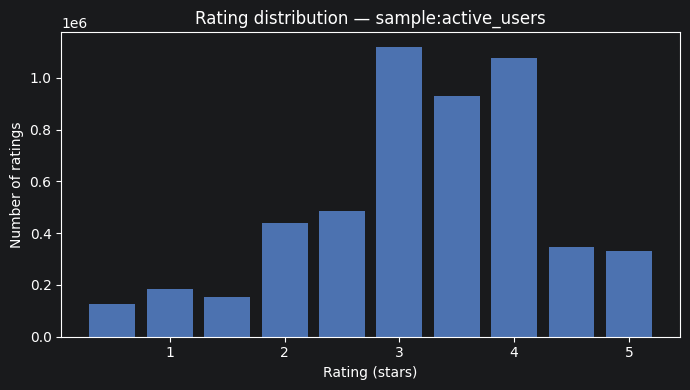

In [11]:
ml.eda.plot_rating_distribution(sample)
plt.show()

### 3.2 The long tail of popularity
A handful of blockbusters collect a huge share of all ratings, while most movies
are rated rarely. On a log-log scale this shows up as a near-straight line —
the famous **long tail**. It's *why* recommending obscure movies (the
"cold-start" problem) is hard: there's barely any data on them.

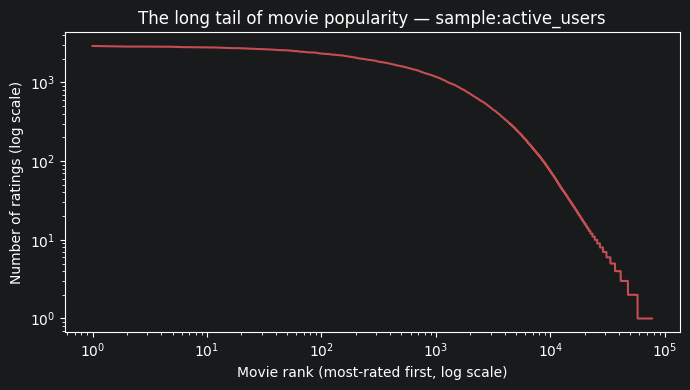

In [12]:
ml.eda.plot_activity_long_tail(sample)
plt.show()

### 3.3 Genres and top movies

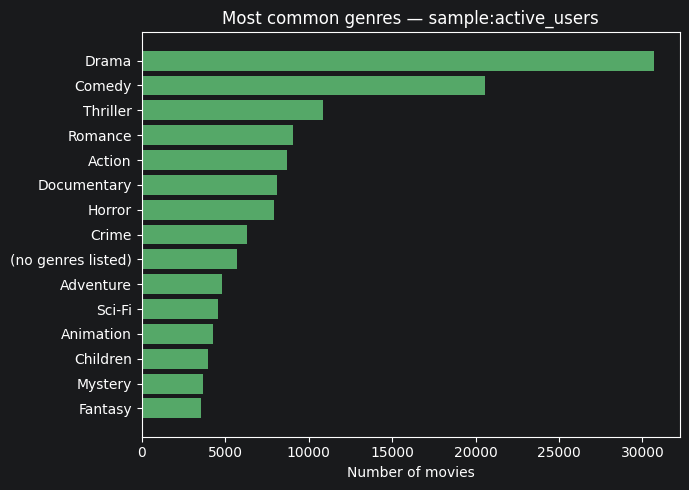

In [13]:
ml.eda.plot_genre_counts(sample, top=15)
plt.show()

In [14]:
# Highest-rated movies (with a minimum number of ratings so a single
# 5-star vote can't top the chart):
ml.eda.top_movies(sample, n=10, min_ratings=50)

,movieId,title,avg_rating,n_ratings
0,858,"Godfather, The (1972)",4.325,2595
1,318,"Shawshank Redemption, The (1994)",4.304,2812
2,26073,"Human Condition III, The (Ningen no joken III)...",4.288,73
3,159817,Planet Earth (2006),4.284,526
4,170705,Band of Brothers (2001),4.281,631
5,171011,Planet Earth II (2016),4.273,328
6,296,Pulp Fiction (1994),4.244,2862
7,179135,Blue Planet II (2017),4.221,206
8,1203,12 Angry Men (1957),4.206,1863
9,1221,"Godfather: Part II, The (1974)",4.199,2301


In [15]:
# Activity stats: how many ratings per user / per movie?
ml.eda.activity_table(sample)

,ratings_per_user,ratings_per_movie
min,"1,090.000",1.000
median,"1,430.500",4.000
mean,"1,730.200",67.100
max,"33,332.000","2,914.000"


## 4. Feature engineering

Collaborative-filtering models learn straight from the (user, movie, rating)
triples, so they don't strictly *need* engineered features. But a real pipeline
builds them — they're useful for inspection, for content-based ideas, and for
understanding *who* and *what* we're modelling.

`ml.features` turns the raw tables into per-user and per-movie feature tables,
including one-hot genre flags and the release year parsed out of the title.

In [16]:
user_feats = ml.features.user_features(sample)
movie_feats = ml.features.movie_features(sample)

print("User features:")
display(user_feats.head())
print("Movie features (popularity, avg rating, + one-hot genres):")
display(movie_feats.head())

User features:


,userId,n_ratings,avg_rating,rating_std
0,28,2842,3.422,0.932
1,188,2202,3.453,1.177
2,265,2436,3.484,1.098
3,354,1262,3.677,0.764
4,447,1096,3.276,1.138


Movie features (popularity, avg rating, + one-hot genres):


,movieId,n_ratings,avg_rating,rating_std,genre_(no genres listed),genre_Action,genre_Adventure,genre_Animation,genre_Children,genre_Comedy,...,genre_Film-Noir,genre_Horror,genre_IMAX,genre_Musical,genre_Mystery,genre_Romance,genre_Sci-Fi,genre_Thriller,genre_War,genre_Western
0,1,2698,3.863,0.892,0,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
1,2,2208,3.093,0.902,0,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
2,3,939,2.764,0.969,0,0,0,0,0,1,...,0,0,0,0,0,1,0,0,0,0
3,4,295,2.446,1.004,0,0,0,0,0,1,...,0,0,0,0,0,1,0,0,0,0
4,5,984,2.580,0.972,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0


## 5. Train / test split — testing honestly

To know if a model is any good, we hide some ratings, train on the rest, then
check whether the model would have predicted the hidden ones. Two strategies:

- **Random split** — hide a random 20% of each user's ratings. Simple, but it
  lets the model peek at "future" ratings to predict the "past".
- **Temporal split** — for each user, hide their *most recent* 20%. This mirrors
  reality: *train on the past, predict the future.* It's the fairer test for a
  recommender, so it's our default.

We always keep every test user in the training set too — you can't fairly test a
recommender on someone it has never seen.

In [17]:
split = ml.splitting.split(sample.ratings, strategy="temporal", test_frac=0.2)
print(split)
print(f"  train: {split.n_train:,} ratings")
print(f"  test:  {split.n_test:,} ratings (the most recent 20% per user)")

Split(n_train=4,152,380, n_test=1,038,105)
  train: 4,152,380 ratings
  test:  1,038,105 ratings (the most recent 20% per user)


## 6. The models — from naive to smart

We climb a ladder of four models, each adding one idea:

1. **Global mean** — predict the overall average rating for *everything*.
   The humblest baseline.
2. **Bias model** — add a per-user offset (some people are generous, some
   harsh) and a per-movie offset (some films are just better). Prediction =
   `μ + user_bias + movie_bias`. Surprisingly strong — the baseline to beat.
3. **Matrix factorization** — discover hidden "taste dimensions" (action-y?
   romantic? quirky?) for every user *and* movie, then match them up. This is
   the heart of modern recommenders.
4. **Item-item collaborative filtering** — "people who liked *this* also liked
   *that*": predict from the movies most similar to ones you already rated.

Each model exposes the same `.fit()` / `.predict()` interface, so they're fully
interchangeable.

> **A real engineering constraint:** item-item CF builds an
> *n_movies × n_movies* similarity matrix. On `active_users` that's
> 77,000² ≈ 6 billion cells — far too big. So we **skip it automatically** on
> large catalogues and showcase it on the compact `dense` sample in §9. This is
> a genuine lesson: the "best" algorithm on paper isn't always the one that fits
> in memory.

In [18]:
# Build the line-up, skipping item-item CF when the catalogue is too large.
to_train = [
    ("global_mean",          ml.models.GlobalMeanModel()),
    ("bias",                 ml.models.BiasModel(reg=10.0)),
    ("matrix_factorization", ml.models.MatrixFactorization(n_factors=20, reg=10.0)),
]
if sample.n_movies <= 5000:
    to_train.append(("item_item_cf", ml.models.ItemItemCF(k_neighbors=30)))
else:
    print(f"(Skipping item_item_cf — {sample.n_movies:,} movies is too many for a "
          f"similarity matrix. We'll demo it on the 'dense' sample in §9.)\n")

models = {}
for name, model in to_train:
    model.fit(split.train)
    models[name] = model
    print(f"fitted {name}")

(Skipping item_item_cf — 77,334 movies is too many for a similarity matrix. We'll demo it on the 'dense' sample in §9.)

fitted global_mean
fitted bias
fitted matrix_factorization


## 7. Evaluation — which model wins?

Two kinds of metric, because a recommender has two jobs:

- **Accuracy** — when we predict a rating, how close are we?
  - **RMSE** (root mean squared error): typical miss in stars, punishing big
    misses extra. *Lower is better.*
  - **MAE** (mean absolute error): average miss in stars. *Lower is better.*
- **Ranking** — of the movies we put at the *top*, how many are genuinely good?
  - **Precision@10**: of our top 10 picks, what fraction the user actually liked.
  - **Recall@10**: of everything the user liked, how much we surfaced in the top 10.
  - *Higher is better* for both.

In [19]:
results = []
for name, model in models.items():
    scores = ml.evaluate.evaluate_model(model, split.test, k=10)
    results.append({"model": name, **scores})

leaderboard = pd.DataFrame(results).sort_values("rmse").reset_index(drop=True)
leaderboard

,model,rmse,mae,precision@10,recall@10,n_ranking_users
0,matrix_factorization,0.800,0.601,0.648,0.099,200
1,bias,0.826,0.623,0.598,0.086,200
2,global_mean,1.018,0.799,0.298,0.031,200


The story should be clear: **each smarter model beats the previous one.** Let's
visualise the RMSE drop — shorter bars are better.

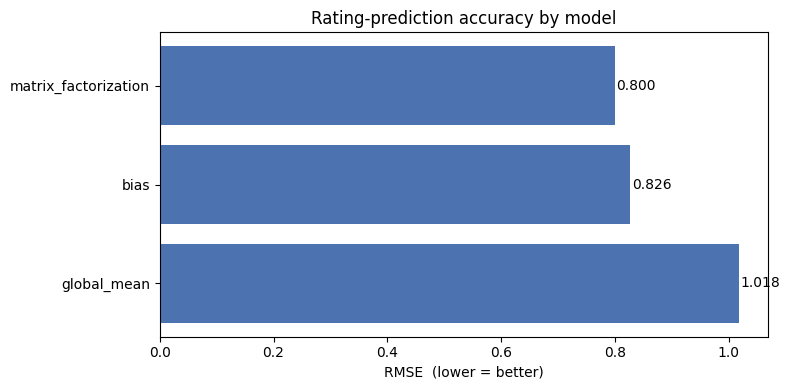

In [20]:
order = leaderboard.sort_values("rmse", ascending=False)
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(order["model"], order["rmse"], color="#4C72B0")
ax.set_xlabel("RMSE  (lower = better)")
ax.set_title("Rating-prediction accuracy by model")
for i, v in enumerate(order["rmse"]):
    ax.text(v + 0.003, i, f"{v:.3f}", va="center")
plt.tight_layout(); plt.show()

## 8. The payoff — real recommendations for a real person

Numbers are nice, but the *point* of all this is to recommend movies. Let's pick
a user, look at what they already love, and see what our best model suggests
they watch next (excluding films they've already seen).

Put "what they liked" next to "what we recommend" and you can sanity-check the
model with your own eyes — do the recommendations *feel* right?

In [21]:
best_name = leaderboard.iloc[0]["model"]
best_model = models[best_name]
print(f"Using our best model: {best_name}\n")

# Pick an active user from the sample so they have a rich history to show.
example_user = int(sample.ratings["userId"].value_counts().index[0])
print(f"Example user: {example_user}")

print("\n⭐ Movies THIS USER already rated highest:")
display(ml.recommend.user_history(sample, example_user, n=8))

Using our best model: matrix_factorization

Example user: 175325

⭐ Movies THIS USER already rated highest:


,movieId,title,genres,rating
0,64273,"Lovers, The (Les Amants) (1958)",Drama,5.000
1,177005,The Missing Scarf (2013),(no genres listed),5.000
2,71350,Scandal Sheet (1952),Crime|Drama|Film-Noir|Romance|Thriller,5.000
3,180589,Leaning Into the Wind: Andy Goldsworthy (2017),Documentary,5.000
4,26865,Fist of Legend (Jing wu ying xiong) (1994),Action|Drama,5.000
5,670,"World of Apu, The (Apur Sansar) (1959)",Drama,5.000
6,130374,India's Daughter (2015),Documentary,5.000
7,97,"Hate (Haine, La) (1995)",Crime|Drama,5.000


In [22]:
print(f"🍿 Top 10 recommendations for user {example_user} (movies they haven't seen):")
ml.recommend.recommend_for_user(best_model, sample, example_user, n=10)

🍿 Top 10 recommendations for user 175325 (movies they haven't seen):


,rank,movieId,title,genres,predicted_rating
0,1,27033,"Kingdom II, The (Riget II) (1997)",Drama|Horror|Mystery,3.973
1,2,179135,Blue Planet II (2017),Documentary,3.949
2,3,720,Wallace & Gromit: The Best of Aardman Animatio...,Adventure|Animation|Comedy,3.899
3,4,198185,Twin Peaks (1989),Drama|Mystery,3.859
4,5,228099,Firefly (2002),Action|Adventure|Sci-Fi|Western,3.845
5,6,136469,Larry David: Curb Your Enthusiasm (1999),Comedy,3.806
6,7,126106,Beastie Boys: Sabotage (1994),(no genres listed),3.802
7,8,8827,"Bill Cosby, Himself (1983)",Comedy|Documentary,3.800
8,9,171331,The Work of Director Chris Cunningham (2003),(no genres listed),3.768
9,10,171749,Death Note: Desu nôto (2006–2007),(no genres listed),3.764


## 9. Swap the sample set — do our conclusions hold?

A good experiment is reproducible on a *different* slice of the data. Because
our samples are swappable and the whole pipeline is one function call, we can
re-run everything on another sample in a single line and check that the model
ranking is stable.

`run_pipeline()` does load → (sample) → split → train all models → evaluate, and
returns a tidy leaderboard.

In [23]:
for key in ["dense", "random_users"]:
    if key not in ml.sampling.list_saved_samples():
        continue
    ds = ml.sampling.load_sample(key)
    # 'random_users' has thousands of movies; item-item CF is meant for dense
    # data, so we let run_pipeline use the default model line-up and simply skip
    # item_item_cf when the catalogue is too big.
    specs = list(ml.pipeline.DEFAULT_MODELS)
    if ds.n_movies > 5000:
        specs = [s for s in specs if s.name != "item_item_cf"]
    print(f"\n===== sample: {key}  ({ds.n_ratings:,} ratings, {ds.n_movies:,} movies) =====")
    res = ml.pipeline.run_pipeline(ds, sample_strategy=None, model_specs=specs, verbose=False)
    display(res.scores[["model", "rmse", "mae", "precision@10", "recall@10"]])


===== sample: dense  (301,416 ratings, 800 movies) =====


,model,rmse,mae,precision@10,recall@10
0,item_item_cf,0.820,0.612,0.684,0.758
1,matrix_factorization,0.837,0.630,0.684,0.757
2,bias,0.860,0.650,0.676,0.749
3,global_mean,0.998,0.780,0.616,0.702



===== sample: random_users  (464,411 ratings, 20,047 movies) =====


,model,rmse,mae,precision@10,recall@10
0,matrix_factorization,0.891,0.680,0.633,0.681
1,bias,0.901,0.689,0.627,0.677
2,global_mean,1.069,0.843,0.555,0.625


## 10. Wrap-up

**What we did, end to end:**

1. **Loaded** 32M real MovieLens ratings (with an automatic synthetic fallback).
2. **Sampled** smartly — by user, into dense/swappable slices — to stay runnable.
3. **Explored** the data: rating distribution, the long tail, genres.
4. **Engineered** per-user and per-movie features.
5. **Split** train/test the honest way (temporal: predict the future).
6. **Trained** four models, naive → smart.
7. **Evaluated** them on accuracy *and* ranking — each model beat the last.
8. **Recommended** actual movies for a real user.
9. **Swapped** samples to confirm the conclusions are robust.

**Why the library matters:** every step above was a one-liner because the logic
lives in the modular `movielens` package. Want to add a deep-learning model? Add
a class to `models.py` and register it. Want a new sampling idea? Add a
`@register`-decorated function to `sampling.py`. The notebook never changes — it
just *uses* the engine. That's what "modular and extensible" buys you.

**Ideas to extend:** SVD++ or neural collaborative filtering, content-based
recommendations using the genre features, hyper-parameter tuning of
`n_factors`, or A/B-comparing temporal vs. random splits.